# ACC102 Mini Task

## Author: Junqi ZHANG (2473060)


#### Practitioners have long argued that the return on stock for high-end technology is risky with high return and the stock for utility industry is stable with relatively low return. 

#### This project aims to explore the return on stock and related risk for leading company from 2019 to 2023 under pandamic shock period to see if this arguments is still valid.

##### Data Preparation

In [3]:
import wrds
import pandas as pd

# Please replace the string below with your own WRDS account name (e.g. 'xiangyun').
username = "junqi_zhang"

db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [4]:
# Define all query parameters as Python variables
stock_list = ('AAPL', 'NEE', 'JNJ', 'JPM') 
start_date = '2019-01-01'
end_date = '2023-12-31'

# Define the coloumn needed
selected_columns_stocks = """
b.ticker,
a.date,
a.ret
"""

selected_columns_sp500 = """
caldt AS date,
sprtrn AS ret
"""

In [5]:
sql_stocks = f"""
SELECT {selected_columns_stocks}
FROM crsp.dsf AS a
LEFT JOIN crsp.dsenames AS b
    ON a.permno = b.permno
WHERE b.ticker IN {stock_list}
AND a.date >= '{start_date}'
AND a.date <= '{end_date}'
AND a.date >= b.namedt
AND a.date <= b.nameendt
"""


In [6]:
sql_market = f"""
SELECT date, vwretd AS daily_return
FROM crsp.dsi
WHERE date >= '{start_date}'
AND date <= '{end_date}'
"""

In [7]:
df_stocks = db.raw_sql(sql_stocks, date_cols=["date"])
df_stocks

,ticker,date,ret
0,AAPL,2019-01-02,0.001141
1,AAPL,2019-01-03,-0.099607
2,AAPL,2019-01-04,0.042689
3,AAPL,2019-01-07,-0.002226
4,AAPL,2019-01-08,0.019063
...,...,...,...
5027,NEE,2023-12-22,0.002517
5028,NEE,2023-12-26,0.007699
5029,NEE,2023-12-27,0.006145
5030,NEE,2023-12-28,0.007263


In [8]:
df_market = db.raw_sql(sql_market, date_cols=["date"])
df_market

,date,daily_return
0,2019-01-02,0.001796
1,2019-01-03,-0.021043
2,2019-01-04,0.03341
3,2019-01-07,0.009202
4,2019-01-08,0.010269
...,...,...
1253,2023-12-22,0.002434
1254,2023-12-26,0.005223
1255,2023-12-27,0.001989
1256,2023-12-28,-0.000111


In [ ]:
if 'ret' in df_stocks.columns:
    df_stocks = df_stocks.rename(columns={'ret': 'daily_return'})

if 'vwretd' in df_market.columns:
    df_market = df_market.rename(columns={'vwretd': 'daily_return'})


df_market['ticker'] = 'Market_Index'


df_final = pd.concat([df_stocks, df_market], ignore_index=True)


df_final = df_final[['ticker', 'date', 'daily_return']]


df_final = df_final.sort_values(by=["ticker", "date"]).dropna()


df_final

,ticker,date,daily_return
0,AAPL,2019-01-02,0.001141
1,AAPL,2019-01-03,-0.099607
2,AAPL,2019-01-04,0.042689
3,AAPL,2019-01-07,-0.002226
4,AAPL,2019-01-08,0.019063
...,...,...,...
5027,NEE,2023-12-22,0.002517
5028,NEE,2023-12-26,0.007699
5029,NEE,2023-12-27,0.006145
5030,NEE,2023-12-28,0.007263


In [10]:
db.close()

#### Analysis Part

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:

# ==========================================
# 1. (Data Transformation)
# ==========================================

# Cumulative Return
# Business Logic: Assuming an initial investment of $1 at the beginning of 2019, calculate the final value by compounding the daily returns.
df_final['cum_return'] = df_final.groupby('ticker')['daily_return'].transform(lambda x: (1 + x).cumprod())

# Annualized Volatility
# Business Logic: Measure risk by multiplying the standard deviation of daily returns by the square root of 252 (representing approximately 252 trading days per year).
volatility_df = df_final.groupby('ticker')['daily_return'].std() * (252 ** 0.5)
volatility_df = volatility_df.reset_index()
volatility_df.columns = ['ticker', 'annual_volatility']

# Sort the volatility in ascending order to facilitate a visual comparison in the chart.
volatility_df = volatility_df.sort_values(by='annual_volatility')
volatility_df

,ticker,annual_volatility
1,JNJ,0.198593
3,Market_Index,0.21079
4,NEE,0.289386
2,JPM,0.318922
0,AAPL,0.322211


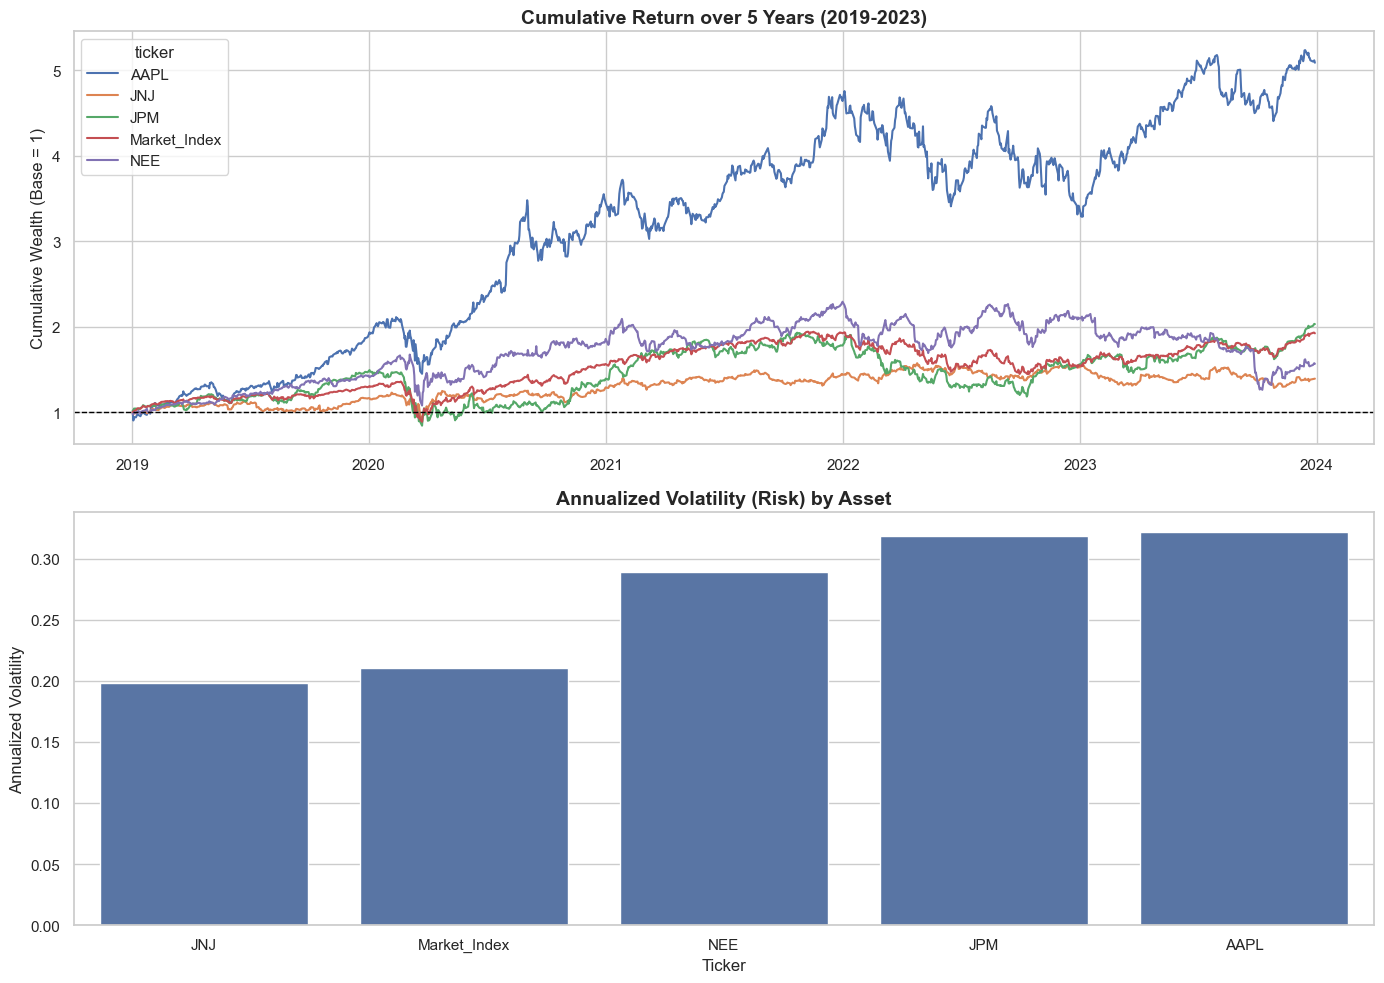

In [13]:

# ==========================================
# 2. Data Visualisation
# ==========================================


sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Chart 1: Comparison of Cumulative Returns (Line Chart) ---
sns.lineplot(data=df_final, x='date', y='cum_return', hue='ticker', linewidth=1.5, ax=axes[0])
axes[0].set_title('Cumulative Return over 5 Years (2019-2023)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative Wealth (Base = 1)', fontsize=12)
axes[0].set_xlabel('')
# Draw a reference line representing the initial investment amount of 1.
axes[0].axhline(y=1, color='black', linestyle='--', linewidth=1) 

# --- Chart 2: Risk Assessment of Different Assets (Bar Chart) ---
sns.barplot(data=volatility_df, x='ticker', y='annual_volatility', ax=axes[1])
axes[1].set_title('Annualized Volatility (Risk) by Asset', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Annualized Volatility', fontsize=12)
axes[1].set_xlabel('Ticker', fontsize=12)


plt.tight_layout()

In [14]:
# ==========================================
# 3. Advanced Metrics
# ==========================================

# Annualized Return
annual_return = df_final.groupby('ticker')['daily_return'].mean() * 252

# Annualized Volatility
annual_volatility = df_final.groupby('ticker')['daily_return'].std() * (252 ** 0.5)

# Sharpe Ratio
# Assume Risk-free rate is 0
sharpe_ratio = annual_return / annual_volatility

# Maximum Drawdown
# Logic: Current Net Value / Historical Peak Net Value - 1
df_final['rolling_max'] = df_final.groupby('ticker')['cum_return'].transform(lambda x: x.cummax())
df_final['drawdown'] = df_final['cum_return'] / df_final['rolling_max'] - 1
max_drawdown = df_final.groupby('ticker')['drawdown'].min()

# Summary Table
metrics_df = pd.DataFrame({
    'Annual_Return': annual_return,
    'Annual_Volatility': annual_volatility,
    'Sharpe_Ratio': sharpe_ratio,
    'Max_Drawdown': max_drawdown
}).reset_index()

print(metrics_df.round(4)) # Keep four decimals

         ticker  Annual_Return  Annual_Volatility  Sharpe_Ratio  Max_Drawdown
0          AAPL          0.378             0.3222         1.173       -0.3143
1           JNJ         0.0857             0.1986        0.4316       -0.2736
2           JPM         0.1924             0.3189        0.6033       -0.4362
3  Market_Index         0.1531             0.2108        0.7265       -0.3467
4           NEE         0.1316             0.2894        0.4547       -0.4499


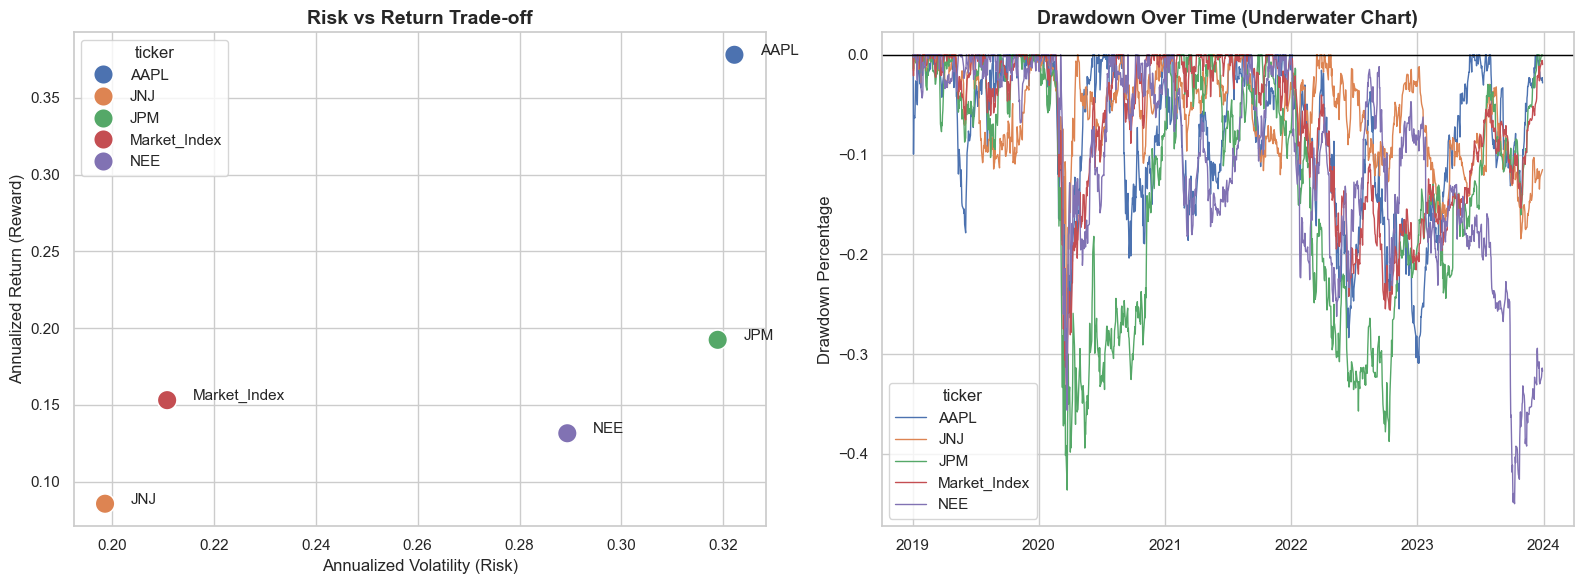

In [15]:

# ==========================================
# 4. Advanced Visualisation
# ==========================================


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 3: Risk-Return Scatter Plot ---
sns.scatterplot(data=metrics_df, x='Annual_Volatility', y='Annual_Return', hue='ticker', s=200, ax=axes[0])
axes[0].set_title('Risk vs Return Trade-off', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annualized Volatility (Risk)', fontsize=12)
axes[0].set_ylabel('Annualized Return (Reward)', fontsize=12)

for i in range(metrics_df.shape[0]):
    axes[0].text(metrics_df['Annual_Volatility'][i] + 0.005, 
                 metrics_df['Annual_Return'][i], 
                 metrics_df['ticker'][i], 
                 fontsize=11)

# --- Chart 4: Historical Drawdown Curve (Underwater Chart) ---
sns.lineplot(data=df_final, x='date', y='drawdown', hue='ticker', linewidth=1, ax=axes[1])
axes[1].set_title('Drawdown Over Time (Underwater Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown Percentage', fontsize=12)
axes[1].set_xlabel('')

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()